In [22]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.size'] = 14

def custom_month_year_formatter(x, pos):
    date = mdates.num2date(x)
    if date.month == 1:
        return date.strftime('%Y')
    else:
        return date.strftime('%b')

RBD = (22520, 23186)

colors = [
    '#E86C6D',
    '#EC9495',
    '#FDB631',
    '#9B9B6B',
    '#B9529F',
]

LINEAGES = [
    'XBB.1.5.X',
    'XBB.1.16.X',
    'XBB.1.9.X',
    'JN.1.X',
    'XEC.X',
]

colors_dict = dict(zip(LINEAGES, colors))

In [23]:
# get first lineage detection date
prevalences = pd.read_csv('../data/lineage-prevalence/PointLoma_sewage_seqs.csv')
first_detect = {lineage: prevalences[prevalences[lineage] > 0]['Date'].min() for lineage in LINEAGES}

print(first_detect)

# load covar data
covar = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
covar = covar[(covar['coverage_start'] >= RBD[0]) & (covar['coverage_end'] <= RBD[1])]
covar = covar[covar['num_clinical_detections'] == 0]
covar = covar[['nt_mutations', 'collection_date']].drop_duplicates().reset_index(drop=True)
covar['collection_date'] = pd.to_datetime(covar['collection_date'])
covar = covar.sort_values('collection_date')


lineage_df = pd.DataFrame()
for lineage, first_date in first_detect.items():
    first_date_dt = pd.to_datetime(first_date)
    end_date_dt = first_date_dt + pd.DateOffset(months=6)
    
    covar_lineage = covar[(covar['collection_date'] >= first_date_dt) & 
                          (covar['collection_date'] < end_date_dt)]
    
    covar_lineage = covar_lineage.groupby('collection_date').count().reset_index()
    covar_lineage = covar_lineage.set_index('collection_date').resample('W').sum().reset_index()
    
    covar_lineage['days_since_first'] = (covar_lineage['collection_date'] - first_date_dt).dt.days
    covar_lineage['cumulative_mutations'] = covar_lineage['nt_mutations'].cumsum()
    covar_lineage = covar_lineage.sort_values('days_since_first')

    lineage_df = pd.concat([lineage_df, covar_lineage.assign(lineage=lineage)])


lineage_df

{'XBB.1.5.X': '2022-11-13', 'XBB.1.16.X': '2023-03-21', 'XBB.1.9.X': '2023-03-08', 'JN.1.X': '2023-11-19', 'XEC.X': '2024-08-07'}


,collection_date,nt_mutations,days_since_first,cumulative_mutations,lineage
0,2023-01-08,16,56,16,XBB.1.5.X
1,2023-01-15,7,63,23,XBB.1.5.X
2,2023-01-22,21,70,44,XBB.1.5.X
3,2023-01-29,33,77,77,XBB.1.5.X
4,2023-02-05,24,84,101,XBB.1.5.X
...,...,...,...,...,...
12,2024-11-03,0,88,21,XEC.X
13,2024-11-10,0,95,21,XEC.X
14,2024-11-17,6,102,27,XEC.X
15,2024-11-24,2,109,29,XEC.X


   collection_date  nt_mutations  days_since_first  cumulative_mutations  \
0       2023-01-08            16                56                    16   
1       2023-01-15             7                63                    23   
2       2023-01-22            21                70                    44   
3       2023-01-29            33                77                    77   
4       2023-02-05            24                84                   101   
5       2023-02-12             3                91                   104   
6       2023-02-19             0                98                   104   
7       2023-02-26             1               105                   105   
8       2023-03-05             2               112                   107   
9       2023-03-12             6               119                   113   
10      2023-03-19            11               126                   124   
11      2023-03-26             6               133                   130   
12      2023

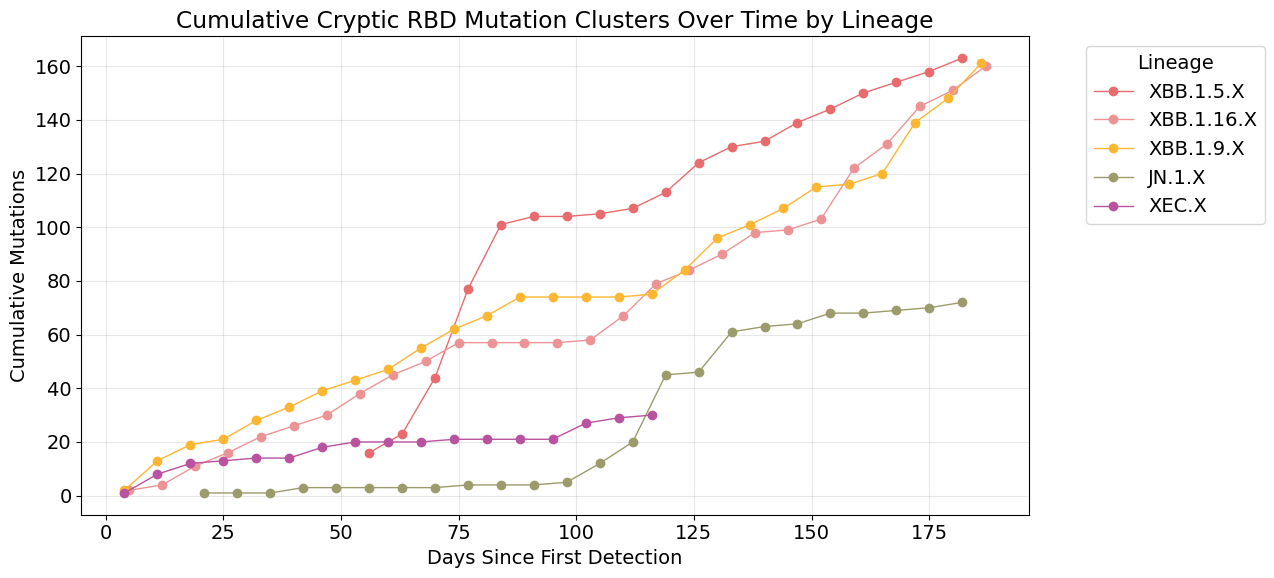

In [24]:
# Create the plot
plt.figure(figsize=(13, 6))

# Plot each lineage
for lineage in lineage_df['lineage'].unique():
    lineage_data = lineage_df[lineage_df['lineage'] == lineage]
    print(lineage_data)
    plt.plot(lineage_data['days_since_first'], 
             lineage_data['cumulative_mutations'], 
             marker='o', 
             label=lineage,
             color=colors_dict[lineage],
                linewidth=1,
             )

# Customize the plot
plt.xlabel('Days Since First Detection')
plt.ylabel('Cumulative Mutations')
plt.title('Cumulative Cryptic RBD Mutation Clusters Over Time by Lineage')
plt.legend(title='Lineage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('variant_introduction/cryptic_diversification_by_lineage.pdf', bbox_inches='tight', transparent=True)